IMPORTING LIBRARIES:

In [2]:
import pandas as pd              #pour manipuler les données
import numpy as np               #pour les calculs numériques 
from sklearn.utils import shuffle     ## pour mélanger aléatoirement les données
from sklearn.model_selection import train_test_split      # pour diviser en train/test
from sklearn.preprocessing import StandardScaler          # pour normaliser les features
from sklearn.neural_network import MLPClassifier          # le modèle MLP prêt à l'emploi
from sklearn.metrics import accuracy_score, classification_report         # pour évaluer les performances
import matplotlib.pyplot as plt                  # pour tracer des graphiques

/////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////

1. LOADING DATA:
----------------

In [3]:
df = pd.read_csv (r"C:\VSCode\Jupyter\Workshop\Iris\iris.csv")     # charge le fichier CSV dans un dataframe

In [4]:
print (df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


#for searching about NULL values we can also use this methode:

In [6]:
print ( df.isnull().sum())

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [7]:
print ( df["species"].unique())

['setosa' 'versicolor' 'virginica']


/////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////

2. SHUFFLE DATA:
----------------

In [8]:
df_sh = shuffle (df, random_state = 42).reset_index(drop=True)

In [9]:
df_sh

,sepal_length,sepal_width,petal_length,petal_width,species
0,6.1,2.8,4.7,1.2,versicolor
1,5.7,3.8,1.7,0.3,setosa
2,7.7,2.6,6.9,2.3,virginica
3,6.0,2.9,4.5,1.5,versicolor
4,6.8,2.8,4.8,1.4,versicolor
...,...,...,...,...,...
145,6.1,2.8,4.0,1.3,versicolor
146,4.9,2.5,4.5,1.7,virginica
147,5.8,4.0,1.2,0.2,setosa
148,5.8,2.6,4.0,1.2,versicolor


/////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////

3. ENCODE TARGET:
-----------------

In [10]:
mapping =  {
            "setosa" : 0,
            "versicolor" : 1,
            "virginica" : 2

            }

In [11]:
Y = df_sh ["species"].map(mapping)   # applique le mapping à la colonne species = Y
X = df_sh.drop (["species"], axis = 1)  # X = features sans la colone species
print (X.head())
print (Y.head())

   sepal_length  sepal_width  petal_length  petal_width
0           6.1          2.8           4.7          1.2
1           5.7          3.8           1.7          0.3
2           7.7          2.6           6.9          2.3
3           6.0          2.9           4.5          1.5
4           6.8          2.8           4.8          1.4
0    1
1    0
2    2
3    1
4    1
Name: species, dtype: int64


/////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////

4. TRAIN/TEST SPLIT:
---------------------

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split (
    X, Y, test_size = 0.2, random_state = 42
)

In [13]:
print ( X_test.shape)
print ( X_train.shape)
print (Y_test.shape)
print (Y_train.shape)

(30, 4)
(120, 4)
(30,)
(120,)


/////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////

5. STANDARDIZATION:
-----------------

In [14]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform (X_train)
X_test_sc = scaler.transform (X_test)
print (X_test_sc)
print ( X_train_sc)

[[-0.07869647 -0.79653727  0.72385195  0.8781336 ]
 [-0.19528383 -0.56453612  0.38388234  0.09466868]
 [-0.19528383 -1.02853842 -0.18273366 -0.29706378]
 [-0.54504591  1.98747649 -1.20264247 -1.0805287 ]
 [ 0.38765297  0.82747076  0.89383675  1.40044355]
 [-0.19528383  3.14748222 -1.31596567 -1.0805287 ]
 [-0.31187119 -0.79653727  0.21389754  0.09466868]
 [ 0.62082769 -0.33253498  0.27055914  0.09466868]
 [-1.47774478  0.36346846 -1.37262727 -1.34168368]
 [-1.01139534  0.36346846 -1.48595048 -1.34168368]
 [ 0.73741505 -0.56453612  0.44054394  0.35582365]
 [-0.42845855  1.0594719  -1.42928888 -1.34168368]
 [ 0.62082769  0.36346846  0.38388234  0.35582365]
 [-0.07869647 -0.79653727  0.04391274 -0.03590881]
 [ 0.62082769 -0.56453612  1.00715995  1.26986606]
 [-0.77822063  0.82747076 -1.37262727 -1.34168368]
 [ 0.50424033  0.82747076  1.00715995  1.53102103]
 [ 0.38765297 -0.33253498  0.27055914  0.09466868]
 [-0.07869647 -0.79653727  0.15723594 -0.29706378]
 [-1.1279827   0.13146732 -1.31

/////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////

6. NEURAL NETWORK:
---------------------

In [ ]:
model = MLPClassifier(
    hidden_layer_sizes = (5,),
    activation = 'relu',     # fonction d'activation de la couche cachée
    solver = 'sgd',          # Stochastic Gradient Descent - le Gradient Descent qu'on a appris
    learning_rate_init = 0.1,
    max_iter = 1000, #The model can stop earlier if it considers that it has converged!
    random_state = 42
)

/////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////

7. TRAINING:
------------

In [16]:
model.fit ( X_train_sc, Y_train)

MLPClassifier(hidden_layer_sizes=(5,), learning_rate_init=0.1, max_iter=1000,
              random_state=42, solver='sgd')

/////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////

8. PREDICTIONS:
---------------

In [17]:
Y_pred = model.predict(X_test_sc)
print ("Prediction are:", Y_pred)

Prediction are: [2 1 1 0 2 0 1 1 0 0 1 0 1 1 2 0 2 1 1 0 0 2 2 0 2 1 0 2 1 0]


/////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////

9. ACCURACY: 
------------

In [18]:
accuracy = accuracy_score(Y_test, Y_pred)
print ( "ACCURACY:", accuracy)
print ( classification_report(Y_test, Y_pred) )

ACCURACY: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00         8

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



/////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////

10. Plot Lost Curve:
--------------------

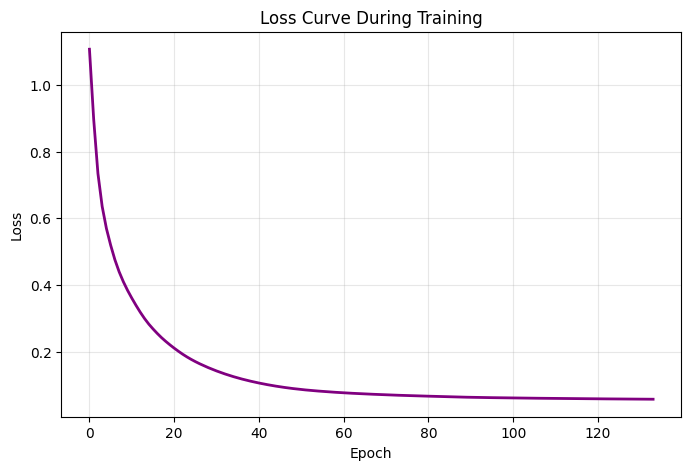

In [19]:
plt.figure(figsize=(8, 5))      # crée une figure vide de taille 8x5
plt.plot(model.loss_curve_, color='purple', linewidth=2)   # trace la loss enregistrée automatiquement à chaque epoch
plt.xlabel('Epoch')     # label de l'axe X
plt.ylabel('Loss')       # label de l'axe Y
plt.title('Loss Curve During Training')     # titre du graphique
plt.grid(alpha=0.3)           # ajoute une grille légère en fond
plt.show()